<a href="https://colab.research.google.com/github/SouvikSadhukhan/SouvikSadhukhan/blob/master/Minor_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#

#1 — Importing packages,Import and explore data

In [8]:
# (Notebook cell)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats   # for skewness/kurtosis and Spearman/Pearson functions

# paths (change if files are in a different folder)
female_path = "nhanes_adult_female_bmx_2020.csv"
male_path   = "nhanes_adult_male_bmx_2020.csv"

# load as pandas DataFrames
female_df = pd.read_csv(female_path, comment="#")
male_df   = pd.read_csv(male_path, comment="#")

print("female shape:", female_df.shape)
print("male   shape:", male_df.shape)
# first row sample
print("female first 5 rows:")
display(female_df.head())
print("male   first 5 rows:")
display(male_df.head())

female shape: (4221, 7)
male   shape: (4081, 7)
female first 5 rows:


,BMXWT,BMXHT,BMXARML,BMXLEG,BMXARMC,BMXHIP,BMXWAIST
0,97.1,160.2,34.7,40.8,35.8,126.1,117.9
1,91.1,152.7,33.5,33.0,38.5,125.5,103.1
2,73.0,161.2,37.4,38.0,31.8,106.2,92.0
3,61.7,157.4,38.0,34.7,29.0,101.0,90.5
4,55.4,154.6,34.6,34.0,28.3,92.5,73.2


male   first 5 rows:


,BMXWT,BMXHT,BMXARML,BMXLEG,BMXARMC,BMXHIP,BMXWAIST
0,98.8,182.3,42.0,40.1,38.2,108.2,120.4
1,74.3,184.2,41.1,41.0,30.2,94.5,86.8
2,103.7,185.3,47.0,44.0,32.0,107.8,109.6
3,86.0,167.8,39.5,38.4,29.0,106.4,108.3
4,99.4,181.6,40.4,39.9,36.0,120.2,107.0


#2.  Read the two files as numpy matrices named male and female. Each matrix consists
of seven
columns:
1. weight (kg),
2. standing height (cm),
3. upper arm length (cm),
4. upper leg length (cm),
5. arm circumference (cm),
6. hip circumference (cm),
7. waist circumference (cm).

In [11]:
# get weights
female_w = female_df['BMXWT']  # weight kg
male_w   = male_df['BMXWT']

# quick numeric checks
print("female weight: n=", female_w.size, "min/max:", female_w.min(), female_w.max(), "mean:", female_w.mean())
print("male   weight: n=", male_w.size,   "min/max:", male_w.min(),   male_w.max(),   "mean:", male_w.mean())

female weight: n= 4221 min/max: 32.6 180.9 mean: 77.40379057095475
male   weight: n= 4081 min/max: 36.8 204.6 mean: 88.36454300416565


#3.  On a single plot (use matplotlib.pytplot.subplot), draw two histograms: for female
weights (top subfigure). and for male weights (bottom subfigure) Call
matplotlib.pyplot.xlim to make the xaxis limits identical for both subfigures (work out the
appropriate limits yourself).

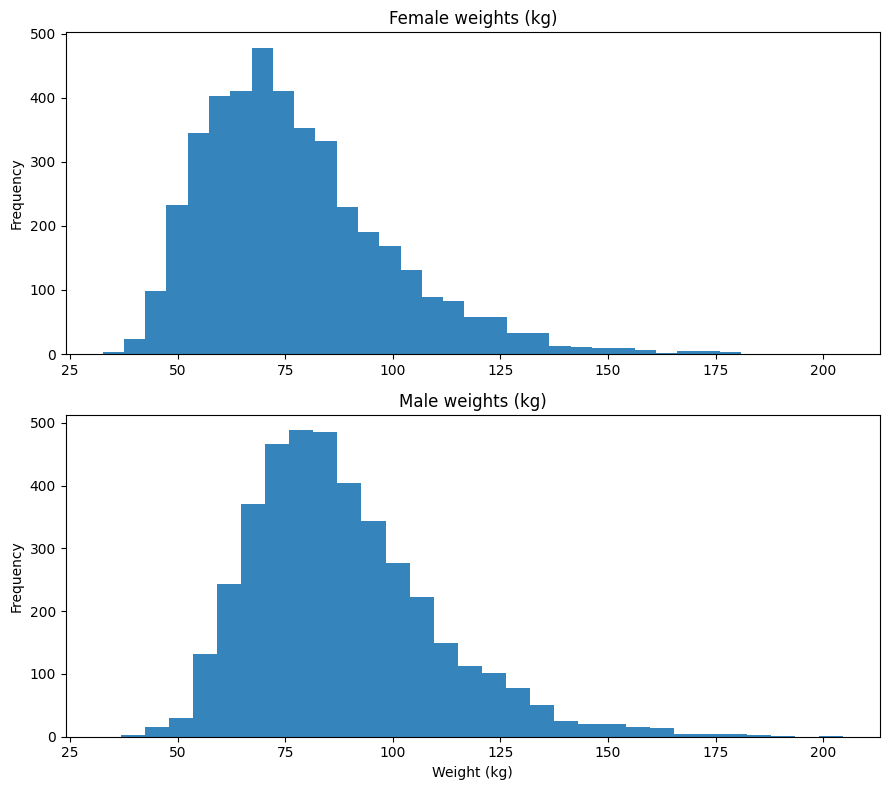

In [12]:
# plotting histograms: female (top) and male (bottom)
plt.figure(figsize=(9, 8))

# choose x limits to cover both datasets with a small margin
global_min = min(female_w.min(), male_w.min())
global_max = max(female_w.max(), male_w.max())
pad = (global_max - global_min) * 0.05
xlim = (max(0, global_min - pad), global_max + pad)

# top: female
plt.subplot(2, 1, 1)
plt.hist(female_w, bins=30, alpha=0.9)
plt.title("Female weights (kg)")
plt.xlim(xlim)
plt.ylabel("Frequency")

# bottom: male
plt.subplot(2, 1, 2)
plt.hist(male_w, bins=30, alpha=0.9)
plt.title("Male weights (kg)")
plt.xlim(xlim)
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


#4. Call matplotlib.pyplot.boxplot to draw a box-and-whisker plot, with two boxes side by
side, giving the male and female weights so that they can be compared to each other.
Note that the boxplot function can be fed with a list of two vectors like [female_weights,
male_weights]. In your own words, discuss the results.

/tmp/ipython-input-576504373.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_w, male_w], labels=["Female", "Male"])


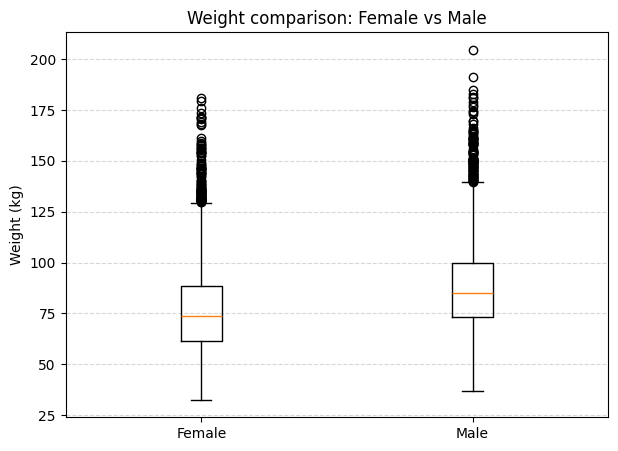

In [13]:
plt.figure(figsize=(7,5))
plt.boxplot([female_w, male_w], labels=["Female", "Male"])
plt.ylabel("Weight (kg)")
plt.title("Weight comparison: Female vs Male")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


#5. Compute the basic numerical aggregates of the male and female weights (measures
of location, dispersion, and shape). In your own words, describe and compare the two
distributions (e.g., are they left skewed, which one has more dispersion, and so forth).

In [14]:
def summary_stats(x):
    stats_dict = {}
    stats_dict['n'] = x.size
    stats_dict['mean'] = np.mean(x)
    stats_dict['median'] = np.median(x)
    stats_dict['std'] = np.std(x, ddof=1)  # sample std
    stats_dict['var'] = np.var(x, ddof=1)
    stats_dict['min'] = np.min(x)
    stats_dict['max'] = np.max(x)
    stats_dict['range'] = stats_dict['max'] - stats_dict['min']
    # IQR
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    stats_dict['IQR'] = q3 - q1
    # skewness and kurtosis using scipy
    stats_dict['skewness'] = stats.skew(x)
    stats_dict['kurtosis'] = stats.kurtosis(x)  # Fisher's (kurtosis - 3 if you want Pearson)
    return stats_dict

female_stats = summary_stats(female_w)
male_stats = summary_stats(male_w)

import pprint
pp = pprint.PrettyPrinter(indent=2)
print("Female weights summary:")
pp.pprint(female_stats)
print("\nMale weights summary:")
pp.pprint(male_stats)


Female weights summary:
{ 'IQR': np.float64(27.1),
  'kurtosis': np.float64(1.4009683480659731),
  'max': 180.9,
  'mean': np.float64(77.40379057095475),
  'median': np.float64(73.6),
  'min': 32.6,
  'n': 4221,
  'range': 148.3,
  'skewness': np.float64(1.03336107186799),
  'std': 21.54506056889292,
  'var': 464.1896349172645}

Male weights summary:
{ 'IQR': np.float64(26.5),
  'kurtosis': np.float64(1.4742884754078238),
  'max': 204.6,
  'mean': np.float64(88.36454300416565),
  'median': np.float64(85.0),
  'min': 36.8,
  'n': 4081,
  'range': 167.8,
  'skewness': np.float64(0.9842810741662347),
  'std': 21.42156142684041,
  'var': 458.88329396389696}


#6. To the female matrix, add the eight column which gives the body mass indices of all
the female participants.

In [16]:
# BMI calculation for females
female_weights = female_df['BMXWT']  # weight in kg
female_heights_cm = female_df['BMXHT'] # height in cm
female_heights_m = female_heights_cm / 100.0 # height in meters
female_bmi = female_weights / (female_heights_m ** 2)

# add BMI as a new column to the female DataFrame
female_df['BMI'] = female_bmi

print("female_df shape:", female_df.shape)
# sanity check: show first 5 rows (with BMI as last column)
display(female_df.head())

# BMI calculation for males
male_weights = male_df['BMXWT']  # weight in kg
male_heights_cm = male_df['BMXHT'] # height in cm
male_heights_m = male_heights_cm / 100.0 # height in meters
male_bmi = male_weights / (male_heights_m ** 2)

# add BMI as a new column to the male DataFrame
male_df['BMI'] = male_bmi

print("male_df shape:", male_df.shape)
# sanity check: show first 5 rows (with BMI as last column)
display(male_df.head())

female_df shape: (4221, 8)


,BMXWT,BMXHT,BMXARML,BMXLEG,BMXARMC,BMXHIP,BMXWAIST,BMI
0,97.1,160.2,34.7,40.8,35.8,126.1,117.9,37.835041
1,91.1,152.7,33.5,33.0,38.5,125.5,103.1,39.069720
2,73.0,161.2,37.4,38.0,31.8,106.2,92.0,28.092655
3,61.7,157.4,38.0,34.7,29.0,101.0,90.5,24.904378
4,55.4,154.6,34.6,34.0,28.3,92.5,73.2,23.178791


male_df shape: (4081, 8)


,BMXWT,BMXHT,BMXARML,BMXLEG,BMXARMC,BMXHIP,BMXWAIST,BMI
0,98.8,182.3,42.0,40.1,38.2,108.2,120.4,29.729226
1,74.3,184.2,41.1,41.0,30.2,94.5,86.8,21.898258
2,103.7,185.3,47.0,44.0,32.0,107.8,109.6,30.201459
3,86.0,167.8,39.5,38.4,29.0,106.4,108.3,30.543200
4,99.4,181.6,40.4,39.9,36.0,120.2,107.0,30.140795


#7. Create a new matrix zfemale being a version of the female dataset with all its columns
standardised (by computing the z-scores of each column).

In [18]:
# standardize each column (column-wise z-score) for female_with_bmi
means = np.mean(female_df, axis=0)
stds  = np.std(female_df, axis=0, ddof=1)
zfemale = (female_df - means) / stds

print("zfemale shape:", zfemale.shape)
# Check mean approx 0 and std approx 1 per column:
print("means (zfemale):", np.round(zfemale.mean(axis=0), 4))
print("stds  (zfemale):", np.round(zfemale.std(axis=0, ddof=1), 4))

zfemale shape: (4221, 8)
means (zfemale): BMXWT      -0.0
BMXHT       0.0
BMXARML     0.0
BMXLEG      0.0
BMXARMC     0.0
BMXHIP      0.0
BMXWAIST   -0.0
BMI         0.0
dtype: float64
stds  (zfemale): BMXWT       1.0
BMXHT       1.0
BMXARML     1.0
BMXLEG      1.0
BMXARMC     1.0
BMXHIP      1.0
BMXWAIST    1.0
BMI         1.0
dtype: float64


#8. Draw a scatterplot matrix (pairplot) for the standardised versions of height, weight,
waist circumference, hip circumference, and BMI of the females (based on zfemale).
Compute Pearson’s and Spearman’s correlation coefficients for all pairs of variables.
Interpret the obtained results.

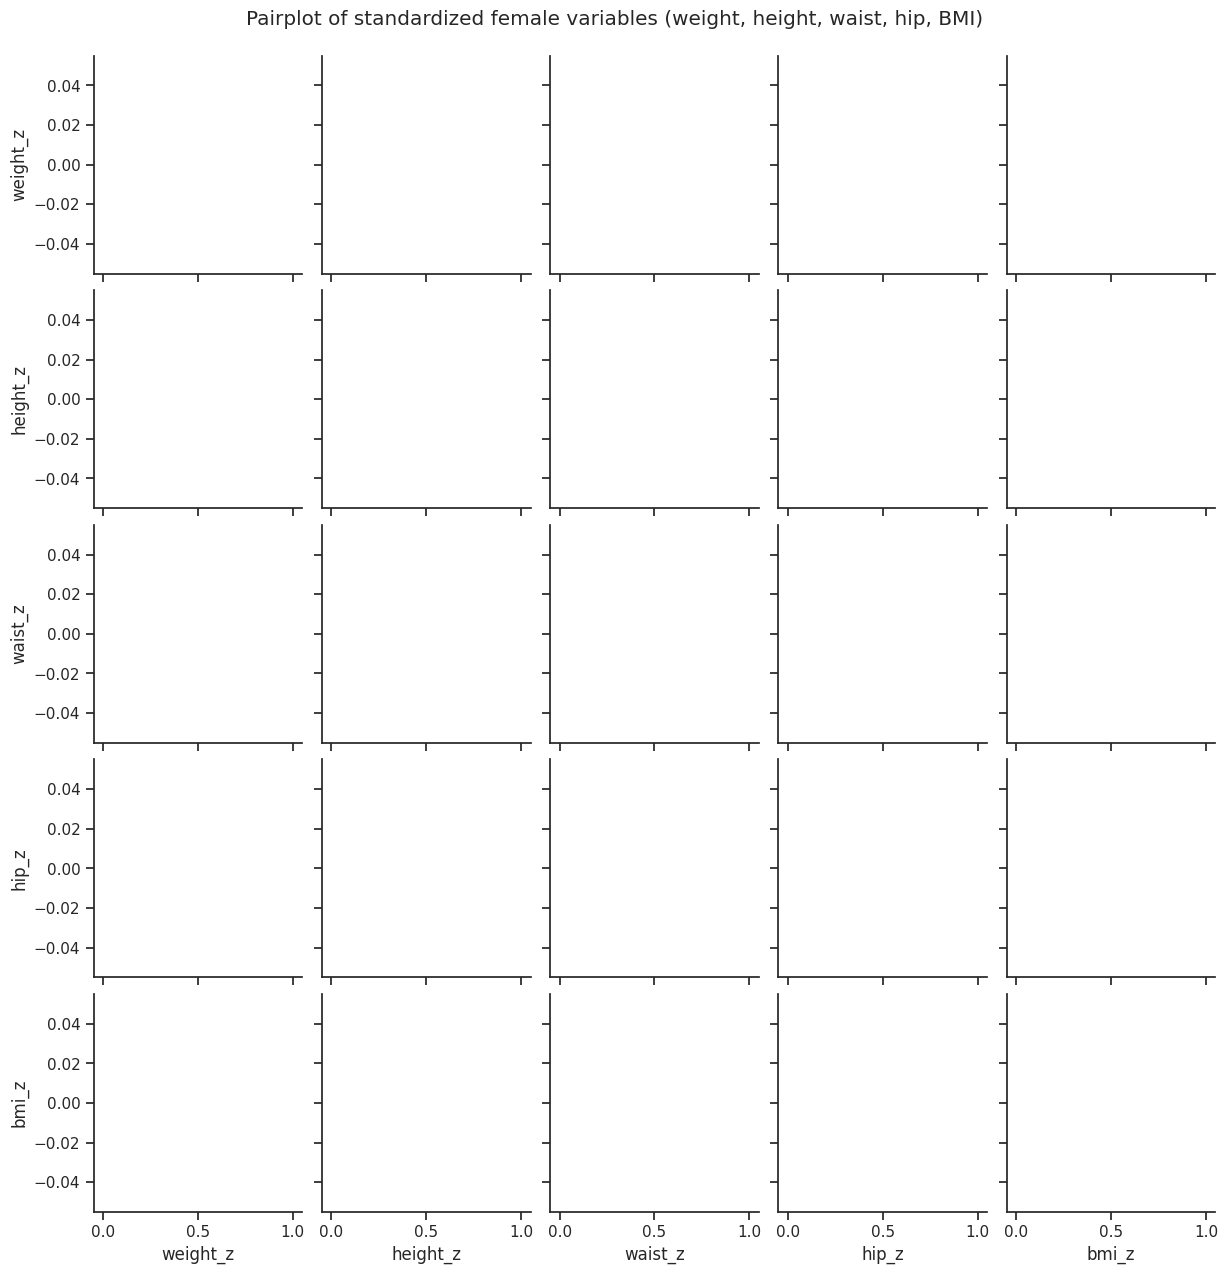

Pearson correlation:
           weight_z  height_z  waist_z  hip_z  bmi_z
weight_z       NaN       NaN      NaN    NaN    NaN
height_z       NaN       NaN      NaN    NaN    NaN
waist_z        NaN       NaN      NaN    NaN    NaN
hip_z          NaN       NaN      NaN    NaN    NaN
bmi_z          NaN       NaN      NaN    NaN    NaN

Spearman correlation:
           weight_z  height_z  waist_z  hip_z  bmi_z
weight_z       NaN       NaN      NaN    NaN    NaN
height_z       NaN       NaN      NaN    NaN    NaN
waist_z        NaN       NaN      NaN    NaN    NaN
hip_z          NaN       NaN      NaN    NaN    NaN
bmi_z          NaN       NaN      NaN    NaN    NaN


In [20]:
# choose columns of interest from female_with_bmi / zfemale
# indices: 0 weight, 1 height, 5 hip, 6 waist, 7 BMI  (BMI is col 7 in female_with_bmi)
cols_interest = [0, 1, 6, 5, 7]  # note: waist (6), hip (5) — keep order: weight,height,waist,hip,bmi

# create a pandas DataFrame for seaborn pairplot (use z-scores to visualize standardized data)
col_names = ['weight_z', 'height_z', 'waist_z', 'hip_z', 'bmi_z']
df_z = pd.DataFrame(zfemale.iloc[:, cols_interest], columns=col_names)

# scatterplot matrix (pairplot)
sns.set(style="ticks")
g = sns.pairplot(df_z, diag_kind='hist', plot_kws={'s': 15})
g.fig.suptitle("Pairplot of standardized female variables (weight, height, waist, hip, BMI)", y=1.02)
plt.show()

# Pearson correlation matrix (on original values or z-scores; same result for Pearson with z-scores)
pearson_corr = df_z.corr(method='pearson')
spearman_corr = df_z.corr(method='spearman')

print("Pearson correlation:\n", pearson_corr.round(3))
print("\nSpearman correlation:\n", spearman_corr.round(3))

#9. Compute the waist circumference to height ratio and the waist circumference to hip
circumference ratio of the male and female participants by adding two more columns to
the males and females matrices.

In [22]:
# female: calculate waist-to-height and waist-to-hip ratios
female_waist = female_df['BMXWAIST']
female_hip = female_df['BMXHIP']
female_height_cm = female_df['BMXHT']

female_w2h = female_waist / female_height_cm
female_w2hip = female_waist / female_hip

# add ratios as new columns to the female DataFrame
female_df['W2H_Ratio'] = female_w2h
female_df['W2Hip_Ratio'] = female_w2hip

print("female_df shape:", female_df.shape)

# male: calculate waist-to-height and waist-to-hip ratios
male_waist = male_df['BMXWAIST']
male_hip = male_df['BMXHIP']
male_height_cm = male_df['BMXHT']

male_w2h = male_waist / male_height_cm
male_w2hip = male_waist / male_hip

# add ratios as new columns to the male DataFrame
male_df['W2H_Ratio'] = male_w2h
male_df['W2Hip_Ratio'] = male_w2hip


print("male_df shape:", male_df.shape)

female_df shape: (4221, 10)
male_df shape: (4081, 10)


#10. Draw a box-and-whisker plot with four boxes side by side, comparing the distribution
of the waistto-height ratio and the waist-to-hip ratio of both male and female participants.
Explain what you see.

/tmp/ipython-input-258850169.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=labels)


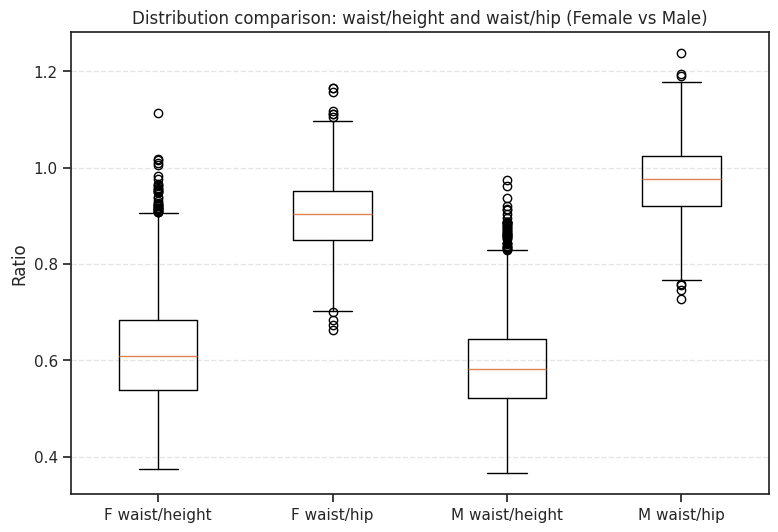

In [23]:
# assemble arrays for boxplot: [female_w2h, female_w2hip, male_w2h, male_w2hip]
data_for_box = [female_w2h, female_w2hip, male_w2h, male_w2hip]
labels = ['F waist/height', 'F waist/hip', 'M waist/height', 'M waist/hip']

plt.figure(figsize=(9,6))
plt.boxplot(data_for_box, labels=labels)
plt.ylabel("Ratio")
plt.title("Distribution comparison: waist/height and waist/hip (Female vs Male)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


#11. In your own words, list some advantages and disadvantages of BMI, waist-to-height
ratio, and waist-to-hip ratio.

BMI

  Advantages:
    - Simple to compute from weight and height.

    - Widely used and standardized cut-offs (underweight/normal/overweight/obese).
    
    - Good for population-level screening.
  
  Disadvantages:
    
    - Does not distinguish fat vs muscle mass.
    - Does not capture fat distribution (visceral vs subcutaneous).
    - Can misclassify muscular individuals.

Waist-to-Height Ratio (WtH)
  
  Advantages:
    
    - Captures central adiposity relative to height.
    - Often better predictor of cardiometabolic risk than BMI.
    - Simple threshold suggested (e.g., 0.5).
  
  Disadvantages:
    
    - Requires accurate waist and height measures.
    - Cutoffs may vary across populations and sexes.

Waist-to-Hip Ratio (WtHip)
  
  Advantages:
    
    - Measures body fat distribution (central vs gluteal).
    - Useful indicator of visceral fat-related risk.
  
  Disadvantages:
    
    - Affected by both waist and hip circumference so can be tricky to interpret.
    - Hip measurement variability (positioning) can affect ratio.


#12. Print out the standardised body measurements for the 5 persons with the lowest BMI
and the 5 persons with the 5 highest BMI (e.g., call print for a subset of zfemale comprised
of 10 chosen rows as determined by a call to numpy.argsort). Interpret the results.

In [27]:
# in female_df BMI column name = 'BMI'
bmi_col_name = 'BMI'

# argsort on BMI
order = np.argsort(female_df[bmi_col_name])
lowest5_idx = order[:5]
highest5_idx = order[-5:]

# columns in zfemale correspond to female_df columns standardized
# create DataFrame for nicer display, with meaningful column names
col_names_full = ['weight_z', 'height_z', 'upper_arm_len_z', 'upper_leg_len_z',
                  'arm_circ_z', 'hip_circ_z', 'waist_circ_z', 'bmi_z', 'w2h_ratio_z', 'w2hip_ratio_z']

df_zfemale = pd.DataFrame(zfemale, columns=col_names_full)

print("5 females with lowest BMI (standardized measurements):")
display(df_zfemale.loc[lowest5_idx])

print("\n5 females with highest BMI (standardized measurements):")
display(df_zfemale.loc[highest5_idx])

5 females with lowest BMI (standardized measurements):


,weight_z,height_z,upper_arm_len_z,upper_leg_len_z,arm_circ_z,hip_circ_z,waist_circ_z,bmi_z,w2h_ratio_z,w2hip_ratio_z
262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



5 females with highest BMI (standardized measurements):


,weight_z,height_z,upper_arm_len_z,upper_leg_len_z,arm_circ_z,hip_circ_z,waist_circ_z,bmi_z,w2h_ratio_z,w2hip_ratio_z
2268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
